In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports for modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, roc_auc_score)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the processed dataset from previous notebook
df = pd.read_csv('D:/Project/AI-Personalized-Learning-UPSC/backend/data/processed/upsc_prelims_processed.csv')
df.head()

,student_id,age,gender,graduation_percentage,graduation_stream,prep_months,daily_study_hours,mock_tests_attempted,revision_cycles,attempt_number,...,gender_encoded,coaching_encoded,graduation_stream_encoded,target_encoded,has_coaching,regular_quiz_taker,high_mock_tester,consistent_student,ncert_reader,standard_books_user
0,1,27,Female,75,Medical,3,11.7,92,1,3,...,0,1,3,1,1,1,1,1,1,1
1,2,24,Female,71,Engineering,32,6.9,30,1,3,...,0,0,2,0,1,1,0,0,1,1
2,3,33,Male,76,Arts,47,7.8,63,8,6,...,1,0,0,1,1,1,1,0,0,1
3,4,31,Female,91,Science,34,3.0,70,1,4,...,0,1,4,0,1,1,1,0,1,1
4,5,28,Male,69,Engineering,30,4.4,32,5,3,...,1,1,2,0,1,0,0,0,1,1


In [3]:
df.shape

(1000, 84)

In [4]:
# Load the features 

data = pd.read_csv('D:/Project/AI-Personalized-Learning-UPSC/backend/data/processed/features_target.csv')
data.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded,target
0,-0.107746,-1.734909,1.562805,-0.301288,0.578712,0.375756,0.605105,-0.025633,-0.869336,0.668253,...,1.562805,-1.347800,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,0.686317,1
1,-0.837399,0.542287,-0.424127,-0.301288,-0.556627,-0.565636,-0.649890,0.440418,-0.249710,-0.531483,...,-0.424127,0.195989,0.0,0.588128,-1.059784,0.418435,0.498437,-1.368782,0.066897,0
2,1.351562,1.720147,-0.051577,1.464073,1.647866,0.077056,1.393009,-1.423786,-0.869336,1.867988,...,-0.051577,1.408075,0.0,0.588128,0.943588,-2.389856,0.498437,0.730577,-1.171941,1
3,0.865126,0.699335,-2.038510,0.287165,-0.627904,2.189688,0.206756,0.906469,0.369917,-0.531483,...,-2.038510,-0.791637,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,1.305736,0
4,0.135472,0.385239,-1.458988,-0.301288,0.329243,-0.935183,-0.037622,0.440418,-0.869336,1.867988,...,-1.458988,-0.542237,0.0,-1.700309,-1.059784,0.418435,0.498437,0.730577,0.066897,0


In [6]:
data.shape

(1000, 33)

### Separate Features and Target

In [8]:
# Separate features (X) and target (y)
X = data.drop('target', axis=1)
y = data['target']

In [9]:
X.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,revision_effectiveness,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded
0,-0.107746,-1.734909,1.562805,-0.301288,0.578712,0.375756,0.605105,-0.025633,-0.869336,0.668253,...,-1.092875,1.562805,-1.347800,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,0.686317
1,-0.837399,0.542287,-0.424127,-0.301288,-0.556627,-0.565636,-0.649890,0.440418,-0.249710,-0.531483,...,-1.115981,-0.424127,0.195989,0.0,0.588128,-1.059784,0.418435,0.498437,-1.368782,0.066897
2,1.351562,1.720147,-0.051577,1.464073,1.647866,0.077056,1.393009,-1.423786,-0.869336,1.867988,...,2.154705,-0.051577,1.408075,0.0,0.588128,0.943588,-2.389856,0.498437,0.730577,-1.171941
3,0.865126,0.699335,-2.038510,0.287165,-0.627904,2.189688,0.206756,0.906469,0.369917,-0.531483,...,-1.026858,-2.038510,-0.791637,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,1.305736
4,0.135472,0.385239,-1.458988,-0.301288,0.329243,-0.935183,-0.037622,0.440418,-0.869336,1.867988,...,0.031777,-1.458988,-0.542237,0.0,-1.700309,-1.059784,0.418435,0.498437,0.730577,0.066897


In [10]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: target, dtype: int64

### Split Data into Train and Test Sets

In [11]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
X_train.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,revision_effectiveness,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded
274,0.621908,-0.871145,-0.134366,-0.889742,-1.518865,-0.636353,-1.471858,1.372520,1.609171,-0.531483,...,-1.425320,-0.134366,-0.755058,0.0,0.588128,-1.059784,-2.389856,0.498437,0.730577,0.686317
179,-0.837399,-0.242953,-1.086438,1.464073,-0.337705,-0.824168,-0.554157,-0.025633,0.369917,-0.531483,...,-0.521825,-1.086438,-0.670262,0.0,-1.700309,-1.059784,0.418435,0.498437,0.730577,1.305736
883,-1.080617,1.013431,-1.210621,0.287165,-0.393708,-1.139691,-0.705499,0.440418,0.369917,-0.531483,...,1.562436,-1.210621,-0.060062,0.0,0.588128,-1.059784,-2.389856,-2.006272,-1.368782,1.305736
357,0.135472,-0.792621,-0.175761,0.875619,0.502344,2.453253,1.232236,-0.491684,-0.869336,-0.531483,...,0.468434,-0.175761,-0.704347,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,-1.171941
194,-0.350963,0.620811,0.238183,0.287165,1.602045,1.704025,1.895745,-1.889837,-0.869336,0.668253,...,1.817074,0.238183,0.692296,0.0,-1.700309,0.943588,0.418435,-2.006272,0.730577,0.066897


In [14]:
X_test.head()

,age,prep_months,daily_study_hours,attempt_number,gs_average_pct,csat_average_pct,overall_score,weak_subjects_count,very_weak_subjects,strong_subjects_count,...,revision_effectiveness,weekly_study_hours,preparation_intensity,has_coaching,regular_quiz_taker,high_mock_tester,ncert_reader,standard_books_user,gender_encoded,graduation_stream_encoded
187,0.865126,0.071143,-1.045044,-0.301288,-2.038168,-0.257750,-1.776938,1.372520,3.468052,-0.531483,...,-1.425320,-1.045044,-0.472405,0.0,0.588128,-1.059784,0.418435,0.498437,0.730577,1.305736
903,-1.323835,-1.499337,-1.252016,-1.478195,-0.582083,1.039217,-0.137606,0.440418,2.228798,-0.531483,...,1.373815,-1.252016,-1.395186,0.0,0.588128,0.943588,0.418435,0.498437,-1.368782,-1.171941
728,-0.837399,-0.007381,-0.548310,-0.889742,0.502344,-0.943455,0.103267,-0.957735,-0.249710,-0.531483,...,0.269439,-0.548310,-0.267896,0.0,0.588128,0.943588,0.418435,0.498437,0.730577,-0.552522
393,1.594780,-0.792621,-1.914326,1.464073,-1.951617,-1.477525,-2.110537,1.372520,2.228798,-0.531483,...,0.064786,-1.914326,-1.228088,0.0,0.588128,-1.059784,-2.389856,0.498437,0.730577,-0.552522
654,1.594780,-0.635573,-1.748749,-0.889742,-1.859975,-0.932903,-1.853476,1.838572,2.848425,-0.531483,...,-1.048549,-1.748749,-1.116689,0.0,0.588128,-1.059784,0.418435,0.498437,-1.368782,1.305736


### Define Models to Train

In [15]:
# Define machine learning models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM': SVC(random_state=42, probability=True)
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - K-Nearest Neighbors
  - SVM


### Train and Evaluate All Models

In [18]:
# Store results
results = []
trained_models = {}

print("Training models...")
print("="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")

print("\n" + "="*60)
print("All models trained successfully!")

Training models...

Training Logistic Regression...
  ✓ Accuracy: 0.9400
  ✓ Precision: 0.8873
  ✓ Recall: 0.9403
  ✓ F1-Score: 0.9130

Training Decision Tree...
  ✓ Accuracy: 0.9550
  ✓ Precision: 0.8919
  ✓ Recall: 0.9851
  ✓ F1-Score: 0.9362

Training Random Forest...
  ✓ Accuracy: 0.9500
  ✓ Precision: 0.9014
  ✓ Recall: 0.9552
  ✓ F1-Score: 0.9275

Training Gradient Boosting...
  ✓ Accuracy: 0.9700
  ✓ Precision: 0.9296
  ✓ Recall: 0.9851
  ✓ F1-Score: 0.9565

Training K-Nearest Neighbors...
  ✓ Accuracy: 0.8850
  ✓ Precision: 0.8056
  ✓ Recall: 0.8657
  ✓ F1-Score: 0.8345

Training SVM...
  ✓ Accuracy: 0.9600
  ✓ Precision: 0.9275
  ✓ Recall: 0.9552
  ✓ F1-Score: 0.9412

All models trained successfully!


### Compare Model Performance

In [25]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.round(4).to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
print(f"\n🏆 Best Model: {best_model_name} with F1-Score = {best_f1:.4f}")

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting     0.970     0.9296  0.9851    0.9565
                SVM     0.960     0.9275  0.9552    0.9412
      Decision Tree     0.955     0.8919  0.9851    0.9362
      Random Forest     0.950     0.9014  0.9552    0.9275
Logistic Regression     0.940     0.8873  0.9403    0.9130
K-Nearest Neighbors     0.885     0.8056  0.8657    0.8345

🏆 Best Model: Gradient Boosting with F1-Score = 0.9565


### Visualize Model Comparison

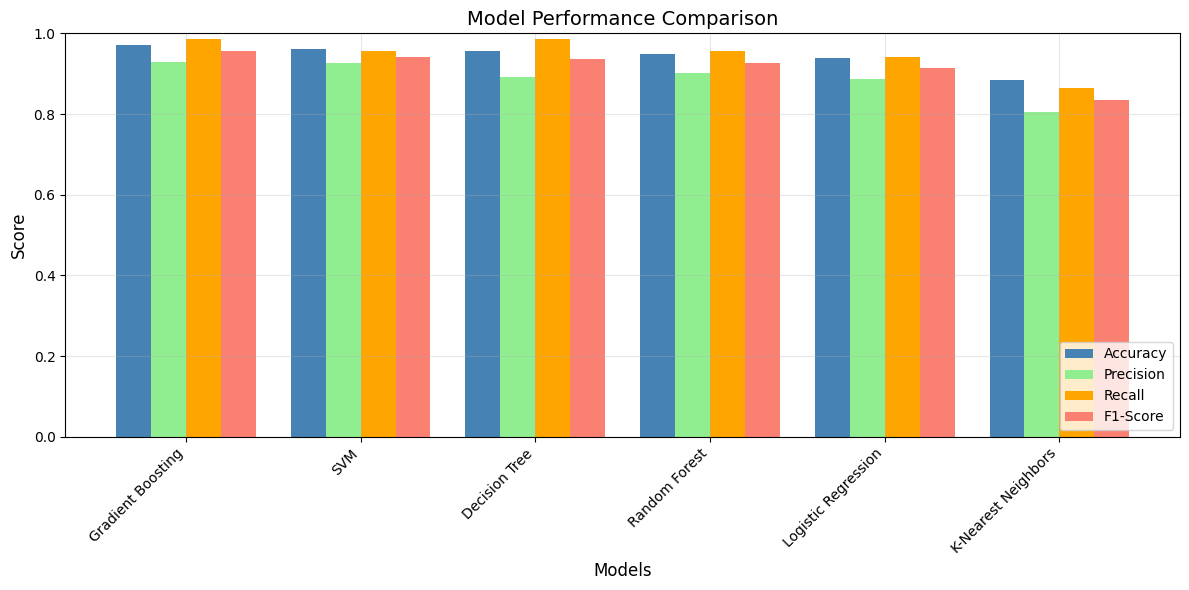

In [33]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

ax.bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x - width/2, results_df['Precision'], width, label='Precision', color='lightgreen')
ax.bar(x + width/2, results_df['Recall'], width, label='Recall', color='orange')
ax.bar(x + width*1.5, results_df['F1-Score'], width, label='F1-Score', color='salmon')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix for Best Model

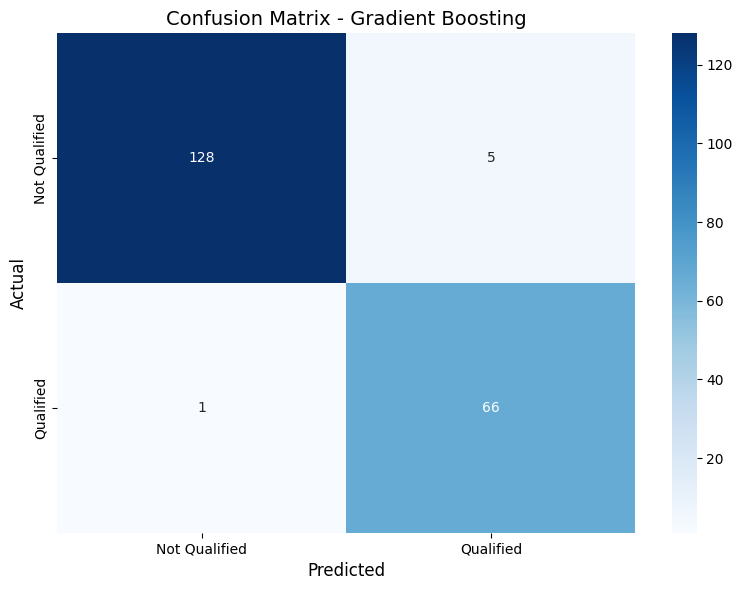


Confusion Matrix Interpretation:
  True Negatives (Correctly predicted Not Qualified): 128
  False Positives (Wrongly predicted Qualified): 5
  False Negatives (Wrongly predicted Not Qualified): 1
  True Positives (Correctly predicted Qualified): 66


In [34]:
# Get best model
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Not Qualified', 'Qualified'],
            yticklabels=['Not Qualified', 'Qualified'])

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14)

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives (Correctly predicted Not Qualified): {cm[0,0]}")
print(f"  False Positives (Wrongly predicted Qualified): {cm[0,1]}")
print(f"  False Negatives (Wrongly predicted Not Qualified): {cm[1,0]}")
print(f"  True Positives (Correctly predicted Qualified): {cm[1,1]}")